# Example dot density plot of Absolute &/or Relative Positional Accuracy Error Distribution

Paul Montesano, PhD  
CSDA  
Sept. 2025

In [4]:
library(ggplot2)
library(viridis)
library(dplyr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




#### The structure of a data frame to show these APA results might look something like this

In [35]:
ideal_data_frame = data.frame(generation='Mark V' ,sensor='NewSat-41', site_name='Morocco', stat='absolute', x_error=1, y_error=2)
ideal_data_frame

generation,sensor,site_name,stat,x_error,y_error
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
Mark V,NewSat-41,Morocco,absolute,1,2


#### Example dataframes with the structure shown above with fake data

In [45]:
# Assuming your dataframe is named 'df' with columns 'x_error' and 'y_error'
# df <- your_dataframe

# Create example dataframe for demonstration
set.seed(123)
n <- 10000
df1 <- data.frame(
  x_error = rnorm(n, 3, 6),
  y_error = rnorm(n, 6,7)
)
df1$generation = 'Mark V'
df1$sensor='NewSat-41'
df1$site_name = 'Morocco'
df1$stat = 'absolute'

df2 <- data.frame(
  x_error = rnorm(n, 2, 7),
  y_error = rnorm(n, 3, 5)
)
df2$generation = 'Mark IV'
df2$sensor='NewSat-23'
df2$site_name = 'New Mexico'
df2$stat = 'absolute'

In [46]:
df = rbind(df1, df2)

Warning message:
“Removed 42 rows containing missing values or values outside the scale range
(`geom_tile()`).”


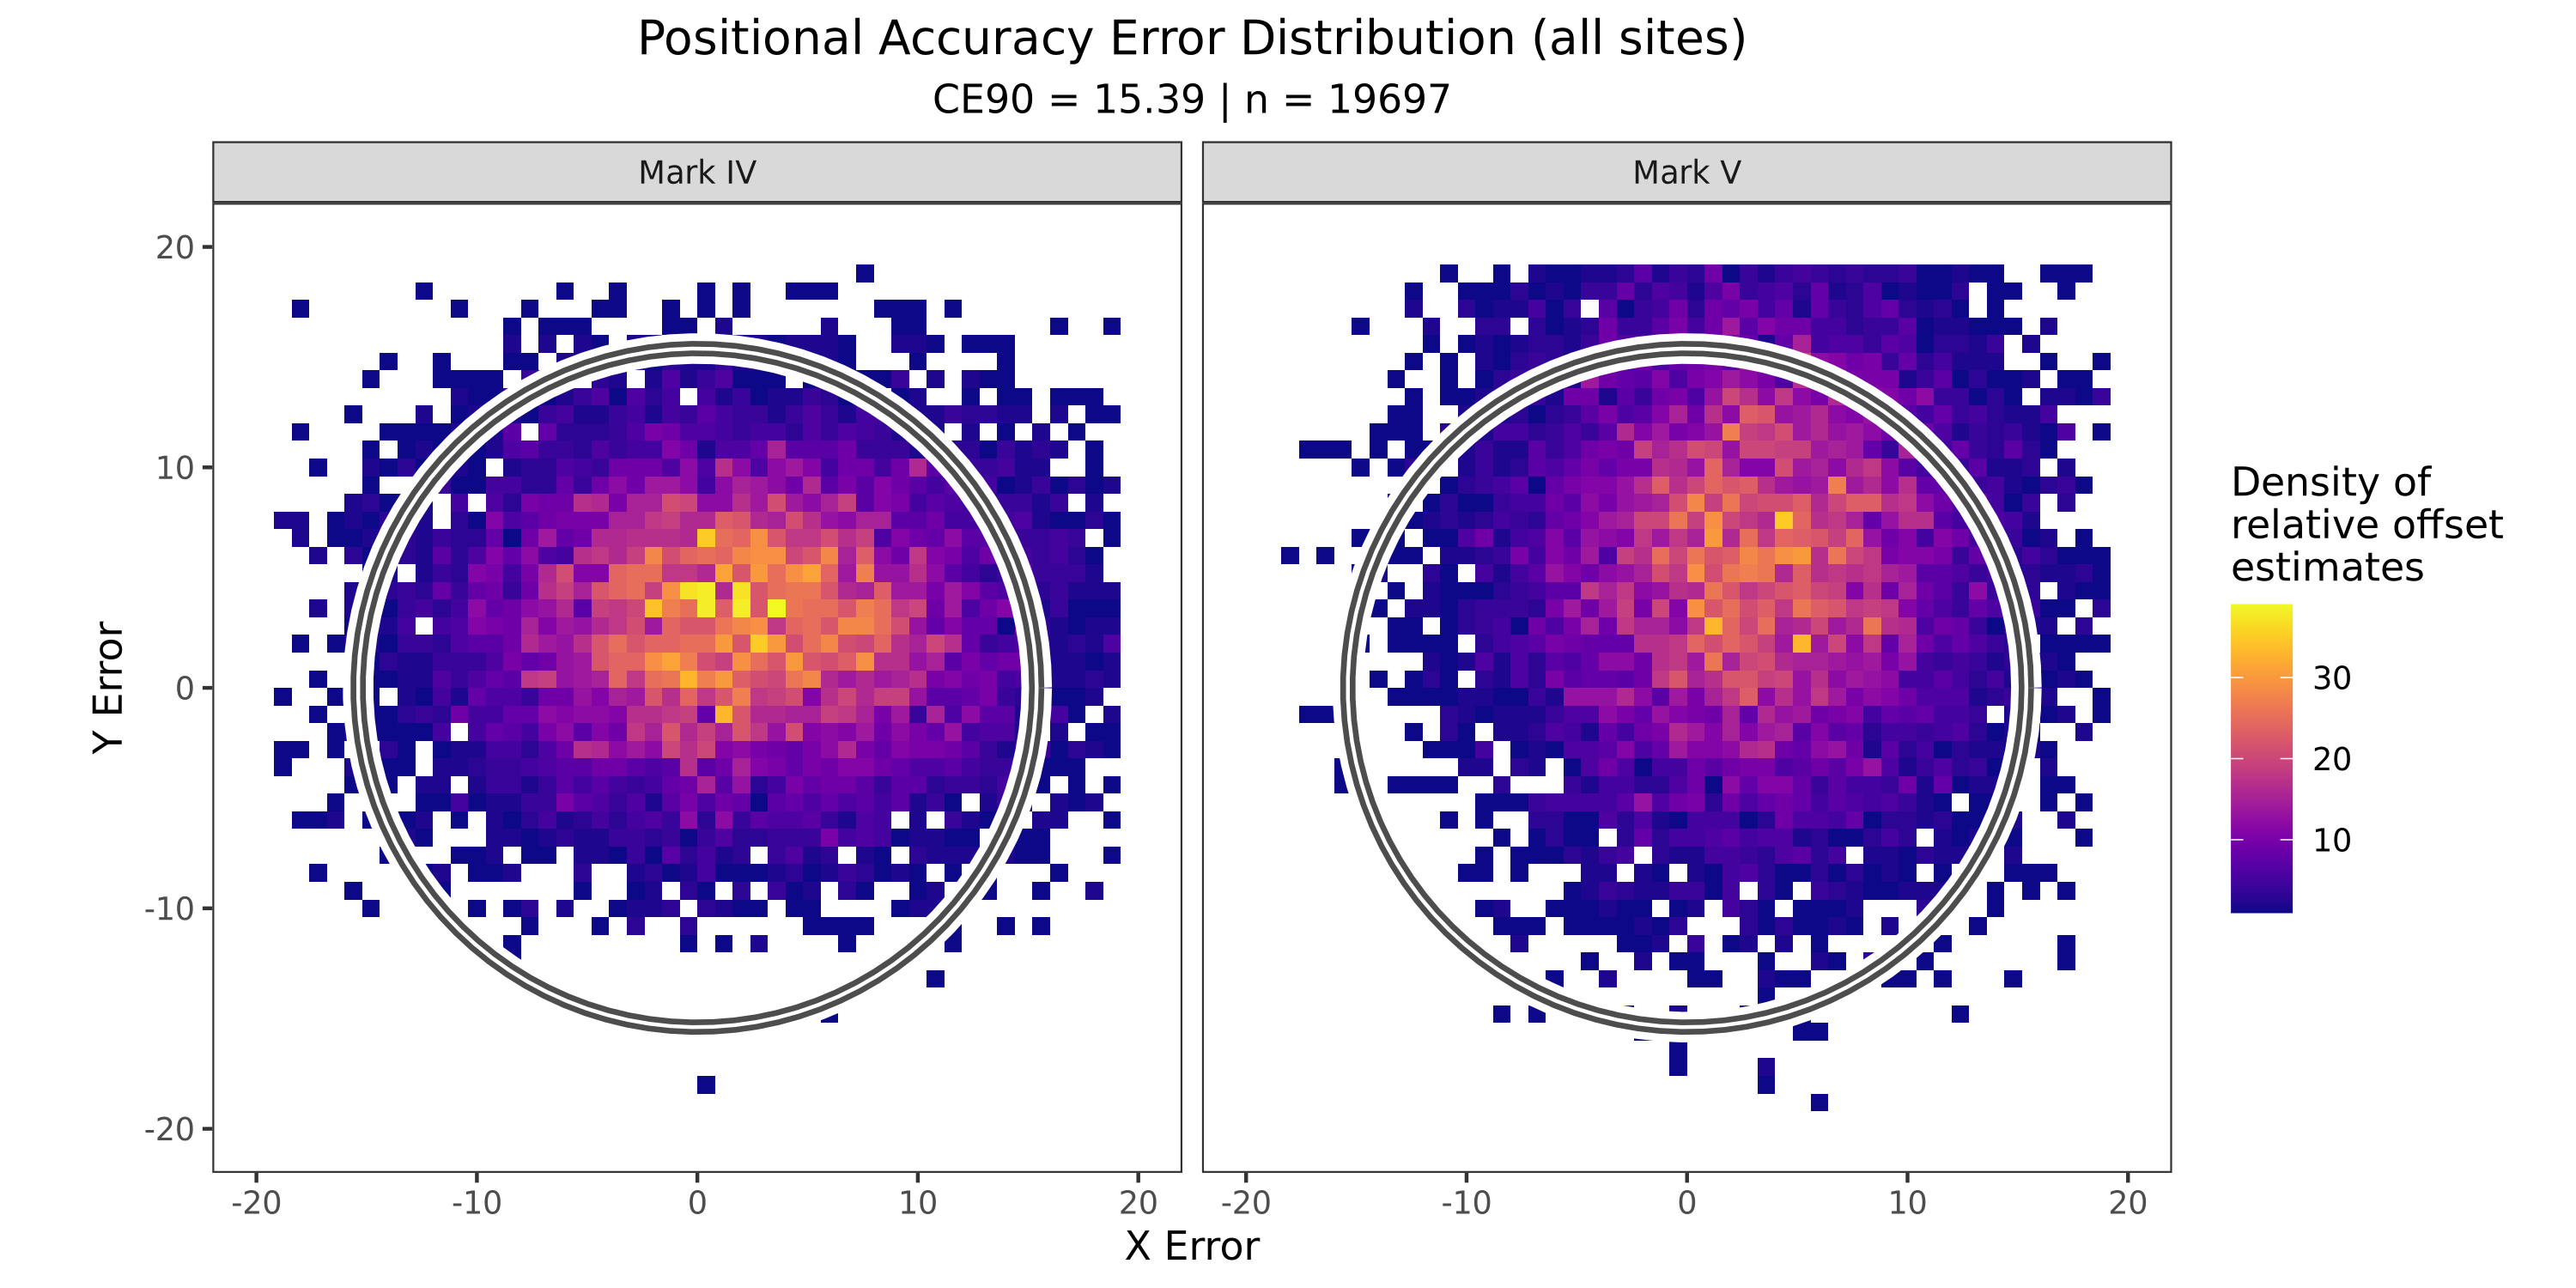

In [47]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 300)

# Filter out zero values and create clean dataset
df_clean <- df %>%
  filter(x_error != 0 & y_error != 0) %>%
  # Optional: also filter out values outside the plot range
  filter(between(x_error, -20, 20) & between(y_error, -20, 20))

# Calculate CE90 from filtered data
distances <- sqrt(df_clean$x_error^2 + df_clean$y_error^2)
ce90_radius <- quantile(distances, 0.9)

# Create the plot
ggplot(df_clean, aes(x = x_error, y = y_error)) +
  # 2D density contours with inferno color scale
  geom_bin2d(alpha = 1, bins = 50) +
  
  # # Density plot with points
  # geom_point(alpha = 0.6, size = 0.8, color = "white") +

  # Black circle (bottom layer) - thicker line
  annotate("path",
           x = ce90_radius * cos(seq(0, 2*pi, length.out = 100)),
           y = ce90_radius * sin(seq(0, 2*pi, length.out = 100)),
           color = "white", size = 4) +
  # Black circle (bottom layer) - thicker line
  annotate("path",
           x = ce90_radius * cos(seq(0, 2*pi, length.out = 100)),
           y = ce90_radius * sin(seq(0, 2*pi, length.out = 100)),
           color = "gray30", size = 2) +
  
  # White circle (top layer) - thinner line
  annotate("path",
           x = ce90_radius * cos(seq(0, 2*pi, length.out = 100)),
           y = ce90_radius * sin(seq(0, 2*pi, length.out = 100)),
           color = "white", size = 0.5) +
  
  # Apply inferno color scale
  scale_fill_viridis(option = "plasma", name = "Density of\nrelative offset\nestimates") +
  
  # Set axis limits and labels
  xlim(-20, 20) +
  ylim(-20, 20) +
  labs(
    title = "Positional Accuracy Error Distribution (all sites)",
    subtitle = paste("CE90 =", round(ce90_radius, 2), "| n =", nrow(df_clean)),
    x = "X Error",
    y = "Y Error"
  ) +
  
  # Equal aspect ratio and clean theme
  coord_fixed() +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  ) +
facet_wrap(~generation, ncol=2)